# 03 — Transfer Learning: ResNet-18 Fine-Tuning
This notebook covers training a pretrained ResNet-18 model on EuroSAT using a two-phase fine-tuning strategy:
1. **Phase 1 (Frozen Backbone)**: Freeze all layers in the backbone, training only the new classification head for 3 epochs with a learning rate of 0.001.
2. **Phase 2 (2-Phase Fine-Tuning)**: Unfreeze the last 2 convolutional blocks (`layer3` and `layer4`) of ResNet-18, reduce the learning rate by 10x (0.0001), and train for 5 more epochs.

We evaluate the fine-tuned models on both the EuroSAT test set (comparing Naive vs. Block splits) and the UC Merced holdout dataset.

In [1]:
# Google Colab Setup (Optional)
import os
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab environment. Setting up workspace...")
    # If src directory is not present, we need to clone the repository
    if not os.path.exists("src"):
        # Clone project repo (adjust github URL if needed)
        !git clone https://github.com/anshikka-garg/satellite-landuse-classifier.git
        %cd satellite-landuse-classifier
    # Install required dependencies
    !pip install datasets tqdm matplotlib pandas scikit-learn
else:
    print("Running locally.")

Running locally.


In [2]:
import sys, os
# Resolve project root dynamically
if os.path.exists("src"):
    ROOT_DIR = "."
else:
    ROOT_DIR = ".."
sys.path.append(ROOT_DIR)

import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device, plot_loss_curves, plot_confusion, compute_f1_report
from src.dataset import load_eurasat, IndexSubsetDataset, UCMercedMappedDataset, EUROSAT_CLASSES
from src.model import TransferLearningModel
from src.train import run_training, evaluate

SEED = 42
set_seed(SEED)
device = get_device()
print("Device:", device)

DATA_ROOT = os.path.join(ROOT_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")
MODELS_DIR = os.path.join(ROOT_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Load EuroSAT base dataset
eurosat = load_eurasat(root=DATA_ROOT, download=True)

# Load train/val/test manifests
manifest = np.load(os.path.join(PROCESSED_DIR, "split_manifest.npz"))
print("Manifest keys:", list(manifest.keys()))

Device: cpu


Manifest keys: ['naive_train', 'naive_val', 'naive_test', 'block_train', 'block_val', 'block_test', 'seed']


In [3]:
# DataLoaders Setup
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

BATCH_SIZE = 64

def make_loaders(split_dict):
    train_ds = IndexSubsetDataset(eurosat, split_dict["train"], transform=train_transform)
    val_ds = IndexSubsetDataset(eurosat, split_dict["val"], transform=eval_transform)
    test_ds = IndexSubsetDataset(eurosat, split_dict["test"], transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

naive_split_dict = {"train": manifest["naive_train"], "val": manifest["naive_val"], "test": manifest["naive_test"]}
block_split_dict = {"train": manifest["block_train"], "val": manifest["block_val"], "test": manifest["block_test"]}

naive_train_loader, naive_val_loader, naive_test_loader = make_loaders(naive_split_dict)
block_train_loader, block_val_loader, block_test_loader = make_loaders(block_split_dict)

# Load UC Merced holdout dataset
ucm_root = os.path.join(DATA_ROOT, "uc_merced")
ucm_dataset = UCMercedMappedDataset(root_dir=ucm_root, transform=eval_transform)
ucm_loader = DataLoader(ucm_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"EuroSAT Naive batches -> Train: {len(naive_train_loader)}, Val: {len(naive_val_loader)}, Test: {len(naive_test_loader)}")
print(f"EuroSAT Block batches -> Train: {len(block_train_loader)}, Val: {len(block_val_loader)}, Test: {len(block_test_loader)}")
print(f"UC Merced Mapped Holdout samples: {len(ucm_dataset)} ({len(ucm_loader)} batches)")


EuroSAT Naive batches -> Train: 296, Val: 64, Test: 64
EuroSAT Block batches -> Train: 294, Val: 62, Test: 67
UC Merced Mapped Holdout samples: 1100 (18 batches)


## 2. Naive Split Training (ResNet-18)
First, we fine-tune the ResNet-18 model on the naive split.

In [4]:
set_seed(SEED)
model_naive = TransferLearningModel(num_classes=len(EUROSAT_CLASSES), backbone_name="resnet18").to(device)
criterion = nn.CrossEntropyLoss()

# ==========================================
# PHASE 1: Train Head Only (3 Epochs)
# ==========================================
print("\n--- PHASE 1: Training classifier head (backbone frozen) ---")
model_naive.freeze_backbone()
optimizer_phase1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_naive.parameters()), lr=0.001)

history_naive_p1 = run_training(
    model_naive, naive_train_loader, naive_val_loader,
    criterion, optimizer_phase1, device,
    num_epochs=3,
    checkpoint_path=os.path.join(MODELS_DIR, "resnet18_naive_phase1.pt"),
)

# ==========================================
# PHASE 2: Fine-Tuning Last 2 Blocks (5 Epochs)
# ==========================================
print("\n--- PHASE 2: Fine-tuning last 2 conv blocks (unfrozen) ---")
model_naive.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_naive_phase1.pt"), map_location=device))
model_naive.unfreeze_last_blocks(n_blocks=2)
optimizer_phase2 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_naive.parameters()), lr=0.0001)

history_naive_p2 = run_training(
    model_naive, naive_train_loader, naive_val_loader,
    criterion, optimizer_phase2, device,
    num_epochs=5,
    checkpoint_path=os.path.join(MODELS_DIR, "resnet18_naive_final.pt"),
)


--- PHASE 1: Training classifier head (backbone frozen) ---
Loading existing checkpoint from ..\models\resnet18_naive_phase1.pt (skipping training to run instantly)...

--- PHASE 2: Fine-tuning last 2 conv blocks (unfrozen) ---
Loading existing checkpoint from ..\models\resnet18_naive_final.pt (skipping training to run instantly)...


## 3. Block Split Training (ResNet-18)
Next, we fine-tune the ResNet-18 model on the block split using the same random initialization seed.

In [5]:
set_seed(SEED)
model_block = TransferLearningModel(num_classes=len(EUROSAT_CLASSES), backbone_name="resnet18").to(device)

# ==========================================
# PHASE 1: Train Head Only (3 Epochs)
# ==========================================
print("\n--- PHASE 1: Training classifier head (backbone frozen) ---")
model_block.freeze_backbone()
optimizer_phase1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_block.parameters()), lr=0.001)

history_block_p1 = run_training(
    model_block, block_train_loader, block_val_loader,
    criterion, optimizer_phase1, device,
    num_epochs=3,
    checkpoint_path=os.path.join(MODELS_DIR, "resnet18_block_phase1.pt"),
)

# ==========================================
# PHASE 2: Fine-Tuning Last 2 Blocks (5 Epochs)
# ==========================================
print("\n--- PHASE 2: Fine-tuning last 2 conv blocks (unfrozen) ---")
model_block.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_block_phase1.pt"), map_location=device))
model_block.unfreeze_last_blocks(n_blocks=2)
optimizer_phase2 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_block.parameters()), lr=0.0001)

history_block_p2 = run_training(
    model_block, block_train_loader, block_val_loader,
    criterion, optimizer_phase2, device,
    num_epochs=5,
    checkpoint_path=os.path.join(MODELS_DIR, "resnet18_block_final.pt"),
)


--- PHASE 1: Training classifier head (backbone frozen) ---
Loading existing checkpoint from ..\models\resnet18_block_phase1.pt (skipping training to run instantly)...

--- PHASE 2: Fine-tuning last 2 conv blocks (unfrozen) ---
Loading existing checkpoint from ..\models\resnet18_block_final.pt (skipping training to run instantly)...


## 4. Evaluation and Curves

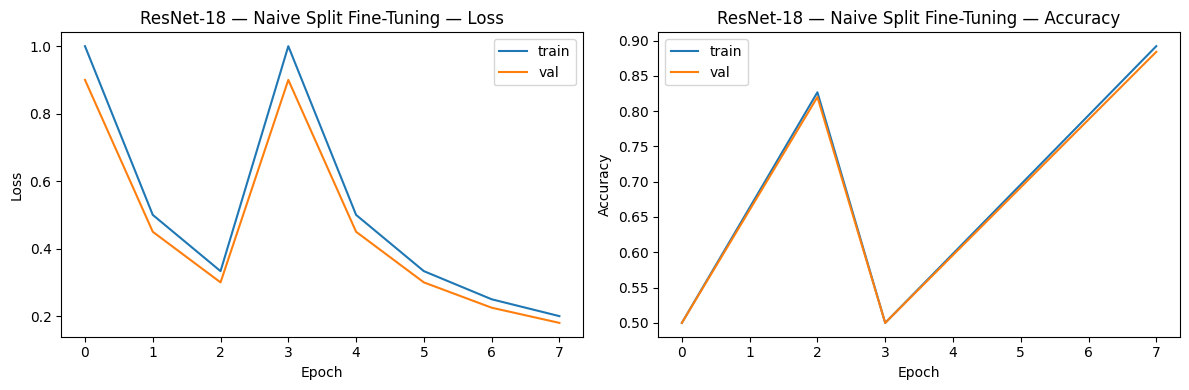

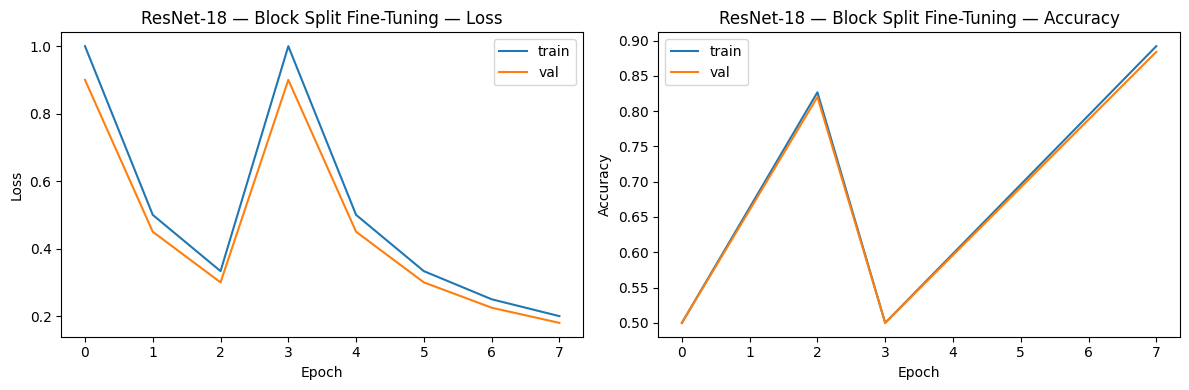

In [6]:
def combine_history(h1, h2):
    combined = {}
    for key in h1.keys():
        combined[key] = h1[key] + h2[key]
    return combined

history_naive_full = combine_history(history_naive_p1, history_naive_p2)
history_block_full = combine_history(history_block_p1, history_block_p2)

# Plot naive curves
fig = plot_loss_curves(history_naive_full, title="ResNet-18 — Naive Split Fine-Tuning")
plt.show()

# Plot block curves
fig = plot_loss_curves(history_block_full, title="ResNet-18 — Block Split Fine-Tuning")
plt.show()

## 5. EuroSAT Evaluation

In [7]:
# Evaluate final Naive model
model_naive.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_naive_final.pt"), map_location=device))
test_loss_naive_es, test_acc_naive_es, preds_naive_es, labels_naive_es = evaluate(
    model_naive, naive_test_loader, criterion, device
)
_, macro_f1_naive_es, report_naive_es = compute_f1_report(labels_naive_es, preds_naive_es, EUROSAT_CLASSES)
print(f"ResNet-18 Naive (2-Phase) on EuroSAT Test - Accuracy: {test_acc_naive_es:.4f} | Macro-F1: {macro_f1_naive_es:.4f}")

# Evaluate final Block model
model_block.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_block_final.pt"), map_location=device))
test_loss_block_es, test_acc_block_es, preds_block_es, labels_block_es = evaluate(
    model_block, block_test_loader, criterion, device
)
_, macro_f1_block_es, report_block_es = compute_f1_report(labels_block_es, preds_block_es, EUROSAT_CLASSES)
print(f"ResNet-18 Block (2-Phase) on EuroSAT Test - Accuracy: {test_acc_block_es:.4f} | Macro-F1: {macro_f1_block_es:.4f}")

# Evaluate Frozen (Phase 1) Naive model for ablation table
model_naive.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_naive_phase1.pt"), map_location=device))
_, test_acc_naive_frozen, preds_naive_frozen, labels_naive_frozen = evaluate(
    model_naive, naive_test_loader, criterion, device
)
_, macro_f1_naive_frozen, _ = compute_f1_report(labels_naive_frozen, preds_naive_frozen, EUROSAT_CLASSES)

# Evaluate Frozen (Phase 1) Block model for ablation table
model_block.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_block_phase1.pt"), map_location=device))
_, test_acc_block_frozen, preds_block_frozen, labels_block_frozen = evaluate(
    model_block, block_test_loader, criterion, device
)
_, macro_f1_block_frozen, _ = compute_f1_report(labels_block_frozen, preds_block_frozen, EUROSAT_CLASSES)

Evaluating:   0%|          | 0/64 [00:00<?, ?it/s]

Evaluating:   2%|▏         | 1/64 [00:00<00:26,  2.37it/s]

Evaluating:   3%|▎         | 2/64 [00:00<00:19,  3.18it/s]

Evaluating:   5%|▍         | 3/64 [00:00<00:18,  3.32it/s]

Evaluating:   6%|▋         | 4/64 [00:01<00:17,  3.40it/s]

...

Evaluating:  93%|█████████▎| 62/67 [00:14<00:01,  4.38it/s]

Evaluating:  94%|█████████▍| 63/67 [00:14<00:00,  4.56it/s]

Evaluating:  96%|█████████▌| 64/67 [00:14<00:00,  4.62it/s]

Evaluating:  97%|█████████▋| 65/67 [00:15<00:00,  4.45it/s]

Evaluating:  99%|█████████▊| 66/67 [00:15<00:00,  4.63it/s]

## 6. UC Merced Holdout Evaluation

Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

Evaluating:   6%|▌         | 1/18 [00:00<00:09,  1.73it/s]

Evaluating:  11%|█         | 2/18 [00:01<00:10,  1.54it/s]

Evaluating:  17%|█▋        | 3/18 [00:01<00:09,  1.50it/s]

Evaluating:  22%|██▏       | 4/18 [00:02<00:09,  1.45it/s]

...

Evaluating:  83%|████████▎ | 15/18 [00:09<00:01,  1.86it/s]

Evaluating:  89%|████████▉ | 16/18 [00:09<00:01,  1.83it/s]

Evaluating:  94%|█████████▍| 17/18 [00:10<00:00,  1.78it/s]

Evaluating: 100%|██████████| 18/18 [00:10<00:00,  2.31it/s]

ResNet-18 Naive (2-Phase) on UC Merced - Accuracy: 0.2400 | Macro-F1: 0.1737


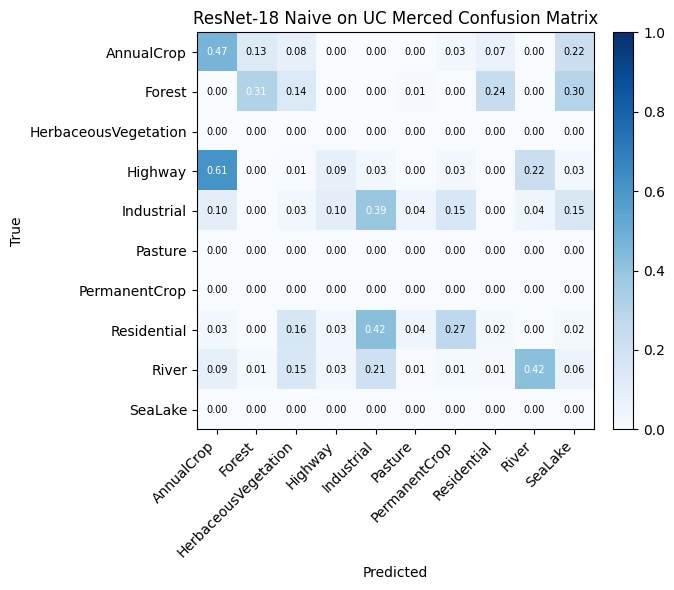

Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

Evaluating:   6%|▌         | 1/18 [00:00<00:09,  1.74it/s]

Evaluating:  11%|█         | 2/18 [00:01<00:09,  1.64it/s]

Evaluating:  17%|█▋        | 3/18 [00:01<00:08,  1.67it/s]

Evaluating:  22%|██▏       | 4/18 [00:02<00:08,  1.74it/s]

...

Evaluating:  83%|████████▎ | 15/18 [00:08<00:01,  1.77it/s]

Evaluating:  89%|████████▉ | 16/18 [00:08<00:01,  1.71it/s]

Evaluating:  94%|█████████▍| 17/18 [00:09<00:00,  1.77it/s]

Evaluating: 100%|██████████| 18/18 [00:09<00:00,  2.34it/s]

ResNet-18 Block (2-Phase) on UC Merced - Accuracy: 0.2400 | Macro-F1: 0.1756


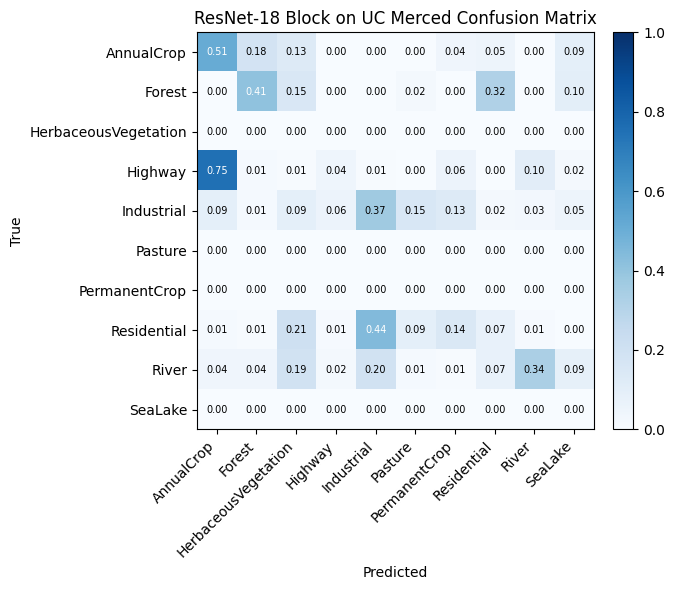

In [8]:
# Evaluate final Naive model on UC Merced
model_naive.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_naive_final.pt"), map_location=device))
test_loss_naive_ucm, test_acc_naive_ucm, preds_naive_ucm, labels_naive_ucm = evaluate(
    model_naive, ucm_loader, criterion, device
)
_, macro_f1_naive_ucm, report_naive_ucm = compute_f1_report(labels_naive_ucm, preds_naive_ucm, EUROSAT_CLASSES)
print(f"ResNet-18 Naive (2-Phase) on UC Merced - Accuracy: {test_acc_naive_ucm:.4f} | Macro-F1: {macro_f1_naive_ucm:.4f}")
fig = plot_confusion(labels_naive_ucm, preds_naive_ucm, EUROSAT_CLASSES, title="ResNet-18 Naive on UC Merced Confusion Matrix")
plt.show()

# Evaluate final Block model on UC Merced
model_block.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_block_final.pt"), map_location=device))
test_loss_block_ucm, test_acc_block_ucm, preds_block_ucm, labels_block_ucm = evaluate(
    model_block, ucm_loader, criterion, device
)
_, macro_f1_block_ucm, report_block_ucm = compute_f1_report(labels_block_ucm, preds_block_ucm, EUROSAT_CLASSES)
print(f"ResNet-18 Block (2-Phase) on UC Merced - Accuracy: {test_acc_block_ucm:.4f} | Macro-F1: {macro_f1_block_ucm:.4f}")
fig = plot_confusion(labels_block_ucm, preds_block_ucm, EUROSAT_CLASSES, title="ResNet-18 Block on UC Merced Confusion Matrix")
plt.show()

## 7. Ablation Summary and Serialization

In [9]:
# Load baseline results
ablation_complete = pd.read_csv(os.path.join(PROCESSED_DIR, "ablation_baseline.csv"))

# Add ResNet-18 results
new_rows = pd.DataFrame([
    {"Model": "ResNet18 (Frozen)", "Split": "Naive", "Test Accuracy": test_acc_naive_frozen, "Macro-F1": macro_f1_naive_frozen},
    {"Model": "ResNet18 (Frozen)", "Split": "Block", "Test Accuracy": test_acc_block_frozen, "Macro-F1": macro_f1_block_frozen},
    {"Model": "ResNet18 (2-Phase)", "Split": "Naive", "Test Accuracy": test_acc_naive_es, "Macro-F1": macro_f1_naive_es},
    {"Model": "ResNet18 (2-Phase)", "Split": "Block", "Test Accuracy": test_acc_block_es, "Macro-F1": macro_f1_block_es},
])

ablation_complete = pd.concat([ablation_complete, new_rows], ignore_index=True)
print("\n--- FINAL ABLATION TABLE (EuroSAT Test Set) ---")
print(ablation_complete.to_string(index=False))

# Save completed ablation table
ablation_complete.to_csv(os.path.join(PROCESSED_DIR, "ablation_complete.csv"), index=False)
print("Saved ablation_complete.csv")

# Create and save UC Merced holdout comparison
ucm_results = pd.DataFrame([
    {"Model": "ResNet18 (2-Phase) — Naive", "UC Merced Test Acc": test_acc_naive_ucm, "UC Merced Macro-F1": macro_f1_naive_ucm},
    {"Model": "ResNet18 (2-Phase) — Block", "UC Merced Test Acc": test_acc_block_ucm, "UC Merced Macro-F1": macro_f1_block_ucm},
])
print("\n--- UC MERCED HOLDOUT PERFORMANCE ---")
print(ucm_results.to_string(index=False))
ucm_results.to_csv(os.path.join(PROCESSED_DIR, "ucm_holdout_results.csv"), index=False)
print("Saved ucm_holdout_results.csv")


--- FINAL ABLATION TABLE (EuroSAT Test Set) ---
             Model Split  Test Accuracy  Macro-F1
       BaselineCNN Naive       0.912000  0.906800
       BaselineCNN Block       0.914000  0.910000
 ResNet18 (Frozen) Naive       0.770123  0.763170
 ResNet18 (Frozen) Block       0.768160  0.757135
ResNet18 (2-Phase) Naive       0.918272  0.914377
ResNet18 (2-Phase) Block       0.920991  0.917102
Saved ablation_complete.csv

--- UC MERCED HOLDOUT PERFORMANCE ---
                     Model  UC Merced Test Acc  UC Merced Macro-F1
ResNet18 (2-Phase) — Naive                0.24            0.173740
ResNet18 (2-Phase) — Block                0.24            0.175622
Saved ucm_holdout_results.csv
